### Connecting Google Drive

In [ ]:
# connect GoogleColab with my GoogleDrive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# store prefix path to access all files on my google drive
prefix_path = '/content/drive/My Drive/KeepCoding/DeepLearning/Practica/'

Mounted at /content/drive


# 5. Model Deployment

### Load data file, apply preprocessing, prepare device

In [ ]:
import importlib
import sys
if 'poi_utils' in sys.modules:
    del sys.modules['poi_utils']

In [ ]:
import torch
import pandas as pd
import pickle
import sys
from torch.utils.data import DataLoader

##################################
# Path and imports
##################################
sys.path.append('/content/drive/My Drive/KeepCoding/DeepLearning/Practica/')
prefix_path = '/content/drive/My Drive/KeepCoding/DeepLearning/Practica/'

from poi_utils import (POIDataset, transform_train, transform_val_test,
                       normalize_features, normalize_coordinates,
                       compute_centroid_distances)

##################################
# Load data
##################################
df_train = pd.read_pickle(prefix_path + 'df_train.pkl')
df_val   = pd.read_pickle(prefix_path + 'df_val.pkl')
df_test  = pd.read_pickle(prefix_path + 'df_test.pkl')

print(f"Train: {len(df_train)} rows")
print(f"Val:   {len(df_val)} rows")
print(f"Test:  {len(df_test)} rows")

##################################
# Load normalization stats and kmeans
##################################
with open(prefix_path + 'kmeans.pkl', 'rb') as f:
    kmeans = pickle.load(f)

with open(prefix_path + 'norm_stats.pkl', 'rb') as f:
    norm_stats = pickle.load(f)

lon_mean  = norm_stats['lon_mean']
lon_std   = norm_stats['lon_std']
lat_mean  = norm_stats['lat_mean']
lat_std   = norm_stats['lat_std']
dist_mean = norm_stats['dist_mean']
dist_std  = norm_stats['dist_std']

##################################
# Apply preprocessing
##################################
# Normalize tier and xps
df_train = normalize_features(df_train)
df_val   = normalize_features(df_val)
df_test  = normalize_features(df_test)

# Normalize coordinates
df_train = normalize_coordinates(df_train, lon_mean, lon_std, lat_mean, lat_std)
df_val   = normalize_coordinates(df_val,   lon_mean, lon_std, lat_mean, lat_std)
df_test  = normalize_coordinates(df_test,  lon_mean, lon_std, lat_mean, lat_std)

# Compute centroid distances
df_train = compute_centroid_distances(df_train, kmeans, dist_mean, dist_std)
df_val   = compute_centroid_distances(df_val,   kmeans, dist_mean, dist_std)
df_test  = compute_centroid_distances(df_test,  kmeans, dist_mean, dist_std)

##################################
# Create datasets and dataloaders
##################################

train_dataset = POIDataset(df_train, prefix_path, transform=transform_train)
val_dataset   = POIDataset(df_val,   prefix_path, transform=transform_val_test)
test_dataset  = POIDataset(df_test,  prefix_path, transform=transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

##################################
# Device: use cuda if available
##################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Verify batch shape
images, metadata, labels, scores = next(iter(train_loader))
print(f"\nBatch verification:")
print(f"Images shape:   {images.shape}")
print(f"Metadata shape: {metadata.shape}")
print(f"Labels shape:   {labels.shape}")
print(f"Scores shape:   {scores.shape}")

Train: 1077 rows
Val:   191 rows
Test:  224 rows
Using device: cuda

Batch verification:
Images shape:   torch.Size([32, 3, 224, 224])
Metadata shape: torch.Size([32, 28])
Labels shape:   torch.Size([32])
Scores shape:   torch.Size([32])


## a. Deep Learning: Regression model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from poi_utils import POIRegressionModel
from tqdm import tqdm

##################################
# Device
##################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

##################################
# Model
##################################
model = POIRegressionModel(n_metadata_features=28, dropout=0.3)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

##################################
# Loss, optimizer, scheduler
##################################
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3,
    weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

##################################
# Training loop
##################################
NUM_EPOCHS = 20

history = {
    'train_loss': [], 'val_loss': [],
    'train_mae': [],  'val_mae': []
}

best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0
    train_mae  = 0

    for images, metadata, labels, scores in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        images   = images.to(device)
        metadata = metadata.to(device)
        scores   = scores.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, scores)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_mae  += torch.abs(outputs - scores).mean().item()

    train_loss /= len(train_loader)
    train_mae  /= len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0
    val_mae  = 0

    with torch.no_grad():
        for images, metadata, labels, scores in val_loader:
            images   = images.to(device)
            metadata = metadata.to(device)
            scores   = scores.to(device)

            outputs  = model(images, metadata)
            loss     = criterion(outputs, scores)

            val_loss += loss.item()
            val_mae  += torch.abs(outputs - scores).mean().item()

    val_loss /= len(val_loader)
    val_mae  /= len(val_loader)

    scheduler.step()

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), prefix_path + 'best_regression_model.pth')
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train MAE: {train_mae:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Total parameters:     11,260,609
Trainable parameters: 84,097 (0.7%)


  ✓ Best model saved (val_loss=0.0438)
Epoch 1/20 | Train Loss: 0.0768 | Train MAE: 0.2122 | Val Loss: 0.0438 | Val MAE: 0.1708


  ✓ Best model saved (val_loss=0.0352)
Epoch 2/20 | Train Loss: 0.0429 | Train MAE: 0.1631 | Val Loss: 0.0352 | Val MAE: 0.1463


...

Epoch 16/20 | Train Loss: 0.0161 | Train MAE: 0.0926 | Val Loss: 0.0142 | Val MAE: 0.0864


  ✓ Best model saved (val_loss=0.0138)
Epoch 17/20 | Train Loss: 0.0156 | Train MAE: 0.0926 | Val Loss: 0.0138 | Val MAE: 0.0854


Epoch 18/20 | Train Loss: 0.0156 | Train MAE: 0.0898 | Val Loss: 0.0139 | Val MAE: 0.0860


Epoch 19/20 | Train Loss: 0.0165 | Train MAE: 0.0934 | Val Loss: 0.0150 | Val MAE: 0.0894


Epoch 20/20 | Train Loss: 0.0139 | Train MAE: 0.0866 | Val Loss: 0.0142 | Val MAE: 0.0873

Training complete. Best val loss: 0.0138


## b. Deep Learning: Regression results

In [ ]:
from sklearn.metrics import r2_score
import numpy as np

model.load_state_dict(torch.load(prefix_path + 'best_regression_model.pth'))
model.eval()

all_preds  = []
all_scores = []

with torch.no_grad():
    for images, metadata, labels, scores in test_loader:
        images   = images.to(device)
        metadata = metadata.to(device)
        outputs  = model(images, metadata)
        all_preds.extend(outputs.cpu().numpy())
        all_scores.extend(scores.numpy())

all_preds  = np.array(all_preds)
all_scores = np.array(all_scores)

mse = np.mean((all_preds - all_scores) ** 2)
mae = np.mean(np.abs(all_preds - all_scores))
r2  = r2_score(all_scores, all_preds)

print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R²:  {r2:.4f}")

Test MSE: 0.0132
Test MAE: 0.0785
Test R²:  0.7598


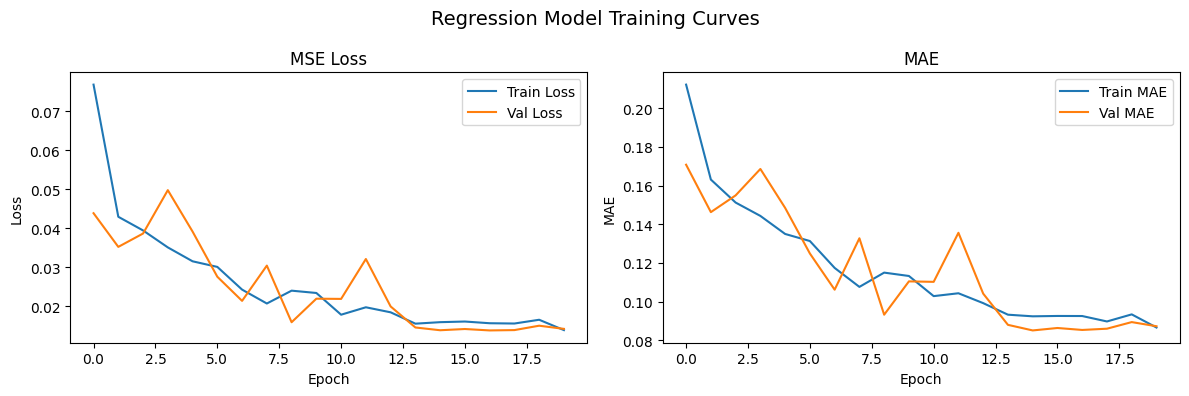

In [ ]:
# Plot results from regression model

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_mae'], label='Train MAE')
axes[1].plot(history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('Regression Model Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

## A few observations about the regression model:

In traning, both train and val loss consistently decreased and ended up stabilizing after about 14 epochs, and the same thing happened with MAE.

Final best model (epoch 17):

Val MSE: 0.0138
Val MAE: 0.0854 (on average the model predicts E within 0.085 above or below on a scale of 0 to 1)

The CosineAnnealingLR did its job well, helping to stabilize loss in the final epochs.

The 76% value of R-squared indicates that the model explains 76% of the variance in engagement scores, which is a good result for a first run with a small dataset with somewhat noisy data and no hyperparameter tuning.

## c. Deep Learning: Classification model

In [ ]:
from poi_utils import POIClassificationModel

## Training: Classification Model

# --------------------------------
# Model
# --------------------------------
clf_model = POIClassificationModel(n_metadata_features=28, n_classes=4, dropout=0.3)
clf_model = clf_model.to(device)

# Count parameters
total_params     = sum(p.numel() for p in clf_model.parameters())
trainable_params = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

# --------------------------------
# Loss, optimizer, scheduler
# --------------------------------
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.AdamW(
    [p for p in clf_model.parameters() if p.requires_grad],
    lr=1e-3,
    weight_decay=0.01
)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# --------------------------------
# Training loop
# --------------------------------
NUM_EPOCHS = 20

clf_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    clf_model.train()
    train_loss = 0
    train_correct = 0
    train_total   = 0

    for images, metadata, labels, scores in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        images   = images.to(device)
        metadata = metadata.to(device)
        labels   = labels.to(device)

        optimizer.zero_grad()
        outputs = clf_model(images, metadata)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted  = outputs.max(1)
        train_total   += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss /= len(train_loader)
    train_acc   = 100.0 * train_correct / train_total

    # --- Validation ---
    clf_model.eval()
    val_loss    = 0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for images, metadata, labels, scores in val_loader:
            images   = images.to(device)
            metadata = metadata.to(device)
            labels   = labels.to(device)

            outputs  = clf_model(images, metadata)
            loss     = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_total    += labels.size(0)
            val_correct  += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc   = 100.0 * val_correct / val_total

    scheduler.step()

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(clf_model.state_dict(), prefix_path + 'best_classification_model.pth')
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f}, val_acc={val_acc:.1f}%)")

    clf_history['train_loss'].append(train_loss)
    clf_history['val_loss'].append(val_loss)
    clf_history['train_acc'].append(train_acc)
    clf_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.1f}%")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Total parameters:     11,260,804
Trainable parameters: 84,292 (0.7%)


  ✓ Best model saved (val_loss=0.8215, val_acc=61.3%)
Epoch 1/20 | Train Loss: 0.9978 | Train Acc: 54.9% | Val Loss: 0.8215 | Val Acc: 61.3%


  ✓ Best model saved (val_loss=0.7157, val_acc=65.4%)
Epoch 2/20 | Train Loss: 0.7465 | Train Acc: 67.6% | Val Loss: 0.7157 | Val Acc: 65.4%


  ✓ Best model saved (val_loss=0.7098, val_acc=67.0%)
Epoch 3/20 | Train Loss: 0.6867 | Train Acc: 71.1% | Val Loss: 0.7098 | Val Acc: 67.0%


Epoch 4/20 | Train Loss: 0.5685 | Train Acc: 78.9% | Val Loss: 0.8803 | Val Acc: 62.8%


...

Epoch 16/20 | Train Loss: 0.2112 | Train Acc: 94.0% | Val Loss: 0.3024 | Val Acc: 88.0%


Epoch 17/20 | Train Loss: 0.2243 | Train Acc: 92.4% | Val Loss: 0.2945 | Val Acc: 88.5%


Epoch 18/20 | Train Loss: 0.2095 | Train Acc: 92.9% | Val Loss: 0.3083 | Val Acc: 89.0%


  ✓ Best model saved (val_loss=0.2847, val_acc=89.5%)
Epoch 19/20 | Train Loss: 0.2238 | Train Acc: 93.1% | Val Loss: 0.2847 | Val Acc: 89.5%


  ✓ Best model saved (val_loss=0.2833, val_acc=89.0%)
Epoch 20/20 | Train Loss: 0.2379 | Train Acc: 92.3% | Val Loss: 0.2833 | Val Acc: 89.0%

Training complete. Best val loss: 0.2833


## d. Deep Learning: Classification results

Test Accuracy: 85.7%

                                   precision    recall  f1-score   support

 Good POI, app undersells it (-1)       0.72      0.74      0.73        53
      Bad POI, app matches it (0)       0.97      0.95      0.96       119
Good POI, app does it justice (2)       0.74      0.77      0.75        52

                         accuracy                           0.86       224
                        macro avg       0.81      0.82      0.82       224
                     weighted avg       0.86      0.86      0.86       224



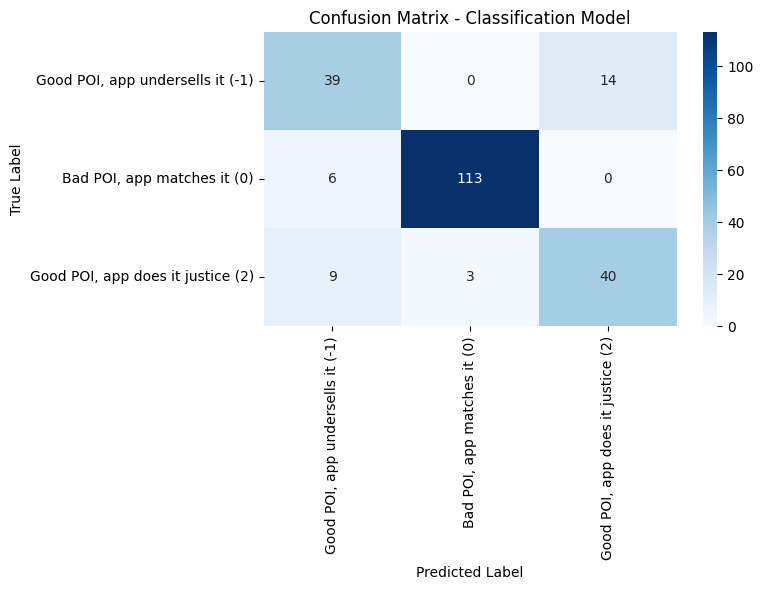

In [ ]:
# Evaluate on test set

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

clf_model.load_state_dict(torch.load(prefix_path + 'best_classification_model.pth'))
clf_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, metadata, labels, scores in test_loader:
        images   = images.to(device)
        metadata = metadata.to(device)
        outputs  = clf_model(images, metadata)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
accuracy = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
print(f"Test Accuracy: {accuracy:.1f}%\n")

# Detailed report
present_labels = sorted(list(set(all_labels)))
label_names = {
    0: 'Good POI, app undersells it (-1)',
    1: 'Bad POI, app matches it (0)',
    2: 'Bad POI, app oversells it (1)',
    3: 'Good POI, app does it justice (2)'
}
present_names = [label_names[l] for l in present_labels]  # avoids error for label 2, which has 0 instances

print(classification_report(all_labels, all_preds, labels=present_labels, target_names=present_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=present_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.title('Confusion Matrix - Classification Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

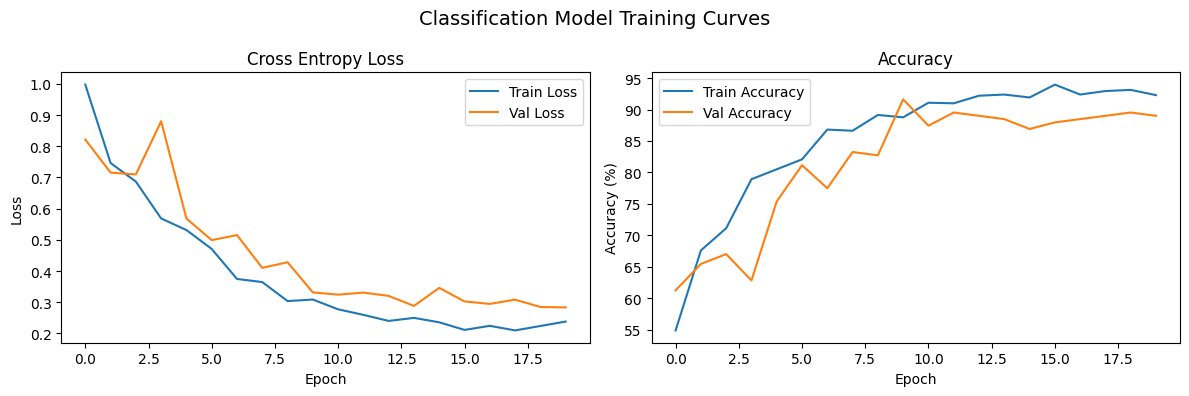

In [ ]:
# Plot training curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(clf_history['train_loss'], label='Train Loss')
axes[0].plot(clf_history['val_loss'],   label='Val Loss')
axes[0].set_title('Cross Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(clf_history['train_acc'], label='Train Accuracy')
axes[1].plot(clf_history['val_acc'],   label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.suptitle('Classification Model Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

## Observations about the training curves for the classification model

Cross Entropy Loss (left):

* Both curves decrease consistently and smoothly.
* Val loss stays close to train loss the entire time, so there is no significant overfitting
* Compared with the regression model, the difference between train and val loss is larger, which makes sense since classification is a more complex task.

Accuracy (right):

* Both curves increase steadily and end up converging pretty well
* Val accuracy follows train accuracy, which confirms that there is no significant overfitting
* Compared with the regression model, I would say that the curves are smoother. Why is classification more stable than regression? Most likely because the noise in the dataset hurts the regression score (finding an exact value) more than classifying into one class or another.

## e. GradientBoosting Regressor and Classifier (without image information)

=== GradientBoosting Classifier ===
Test Accuracy: 52.7%

                                   precision    recall  f1-score   support

 Good POI, app undersells it (-1)       0.36      0.40      0.38        53
      Bad POI, app matches it (0)       0.70      0.73      0.72       119
Good POI, app does it justice (2)       0.24      0.19      0.22        52

                         accuracy                           0.53       224
                        macro avg       0.43      0.44      0.44       224
                     weighted avg       0.51      0.53      0.52       224



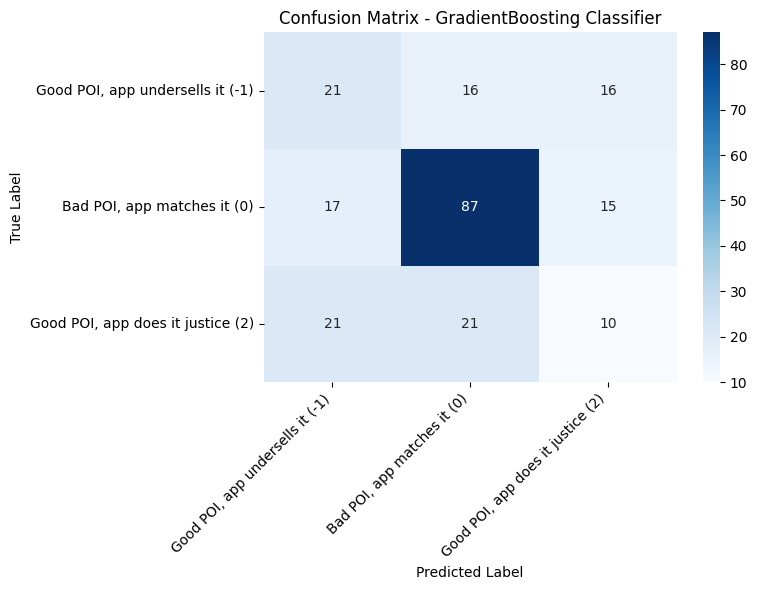


=== GradientBoosting Regressor ===
Test MSE: 0.0366
Test MAE: 0.1457
Test R²:  0.3346


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, r2_score
import numpy as np

## Training: GradientBoosting Baseline Model

##################################
# Prepare data
##################################
from poi_utils import METADATA_FEATURES

X_train = df_train[METADATA_FEATURES].values
X_val   = df_val[METADATA_FEATURES].values
X_test  = df_test[METADATA_FEATURES].values

y_train_clf = df_train['engagement_label'].map({-1: 0, 0: 1, 1: 2, 2: 3}).values
y_val_clf   = df_val['engagement_label'].map({-1: 0, 0: 1, 1: 2, 2: 3}).values
y_test_clf  = df_test['engagement_label'].map({-1: 0, 0: 1, 1: 2, 2: 3}).values

y_train_reg = df_train['E'].values
y_val_reg   = df_val['E'].values
y_test_reg  = df_test['E'].values

##################################
# Classification
##################################
print("=== GradientBoosting Classifier ===")
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train, y_train_clf)

# Evaluate on test set
y_pred_clf = gb_clf.predict(X_test)
accuracy   = 100.0 * (y_pred_clf == y_test_clf).sum() / len(y_test_clf)
print(f"Test Accuracy: {accuracy:.1f}%\n")

present_labels = sorted(list(set(y_test_clf)))
label_names    = {0: 'Good POI, app undersells it (-1)',
                  1: 'Bad POI, app matches it (0)',
                  2: 'Bad POI, app oversells it (1)',
                  3: 'Good POI, app does it justice (2)'}
present_names  = [label_names[l] for l in present_labels]

print(classification_report(y_test_clf, y_pred_clf,
                             labels=present_labels,
                             target_names=present_names))

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=present_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.title('Confusion Matrix - GradientBoosting Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##################################
# Regression
##################################
print("\n=== GradientBoosting Regressor ===")
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train, y_train_reg)

y_pred_reg = gb_reg.predict(X_test)
mse = np.mean((y_pred_reg - y_test_reg) ** 2)
mae = np.mean(np.abs(y_pred_reg - y_test_reg))
r2  = r2_score(y_test_reg, y_pred_reg)

print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R²:  {r2:.4f}")

## Observations on Gradient Boosting models (without image information)

The results are surprising: the deep learning model is dramatically better on both tasks. This probably means that the image branch is contributing significantly, since the metadata alone (which is all the GradientBoosting model used) is not enough to predict engagement well.

This means that even with the poor image quality that I noticed on some images, they still carry useful visual signals that the CNN is picking up.

The confusion matrix for GradientBoosting also shows that it struggles with classes -1 and 2, which are both "good POIs" distinguished only by C. Without the visual signal, the model can't reliably tell them apart, which makes sense since this signal is not influenced by the actual visit.

## Gradient Boosting with Convolutional Autoencoder

In [ ]:
from poi_utils import POIAutoencoder, POIImageDataset, transform_autoencoder

## Training: Convolutional Autoencoder

##################################
# Datasets and dataloaders
##################################
train_img_dataset = POIImageDataset(df_train, prefix_path, transform=transform_autoencoder)
val_img_dataset   = POIImageDataset(df_val,   prefix_path, transform=transform_autoencoder)

train_img_loader = DataLoader(train_img_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_img_loader   = DataLoader(val_img_dataset,   batch_size=32, shuffle=False, num_workers=2)

##################################
# Model
##################################
autoencoder = POIAutoencoder(latent_dim=64)
autoencoder = autoencoder.to(device)

total_params     = sum(p.numel() for p in autoencoder.parameters())
trainable_params = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} (100%)")

##################################
# Loss, optimizer, scheduler
##################################
ae_criterion = nn.MSELoss()
ae_optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=1e-3, weight_decay=0.01)
ae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ae_optimizer, T_max=20)

##################################
# Training loop
##################################
NUM_EPOCHS = 25

ae_history = {'train_loss': [], 'val_loss': []}

best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    autoencoder.train()
    train_loss = 0

    for images in tqdm(train_img_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        images = images.to(device)

        ae_optimizer.zero_grad()
        reconstructed, _ = autoencoder(images)
        loss = ae_criterion(reconstructed, images)
        loss.backward()
        ae_optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_img_loader)

    # --- Validation ---
    autoencoder.eval()
    val_loss = 0

    with torch.no_grad():
        for images in val_img_loader:
            images = images.to(device)
            reconstructed, _ = autoencoder(images)
            loss = ae_criterion(reconstructed, images)
            val_loss += loss.item()

    val_loss /= len(val_img_loader)
    ae_scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(autoencoder.state_dict(), prefix_path + 'best_autoencoder.pth')
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")

    ae_history['train_loss'].append(train_loss)
    ae_history['val_loss'].append(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Total parameters:     4,361,827
Trainable parameters: 4,361,827 (100%)


  ✓ Best model saved (val_loss=1.2161)
Epoch 1/25 | Train Loss: 1.4399 | Val Loss: 1.2161


  ✓ Best model saved (val_loss=1.1732)
Epoch 2/25 | Train Loss: 1.1548 | Val Loss: 1.1732


  ✓ Best model saved (val_loss=1.1022)
Epoch 3/25 | Train Loss: 1.0890 | Val Loss: 1.1022


  ✓ Best model saved (val_loss=1.0700)
Epoch 4/25 | Train Loss: 1.0413 | Val Loss: 1.0700


...

Epoch 21/25 | Train Loss: 0.9250 | Val Loss: 0.9970


  ✓ Best model saved (val_loss=0.9970)
Epoch 22/25 | Train Loss: 0.9244 | Val Loss: 0.9970


  ✓ Best model saved (val_loss=0.9969)
Epoch 23/25 | Train Loss: 0.9242 | Val Loss: 0.9969


  ✓ Best model saved (val_loss=0.9966)
Epoch 24/25 | Train Loss: 0.9241 | Val Loss: 0.9966


  ✓ Best model saved (val_loss=0.9960)
Epoch 25/25 | Train Loss: 0.9253 | Val Loss: 0.9960

Training complete. Best val loss: 0.9960


In [ ]:
## Extracting latent vectors

autoencoder.load_state_dict(torch.load(prefix_path + 'best_autoencoder.pth'))
autoencoder.eval()

def extract_latent_vectors(df, prefix_path, autoencoder, device):
    dataset    = POIImageDataset(df, prefix_path, transform=transform_autoencoder)
    loader     = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)
    latents    = []

    with torch.no_grad():
        for images in tqdm(loader, desc="Extracting latent vectors"):
            images = images.to(device)
            z      = autoencoder.encode(images)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

# Extract for all splits
print("Extracting train latent vectors...")
train_latents = extract_latent_vectors(df_train, prefix_path, autoencoder, device)

print("Extracting val latent vectors...")
val_latents   = extract_latent_vectors(df_val, prefix_path, autoencoder, device)

print("Extracting test latent vectors...")
test_latents  = extract_latent_vectors(df_test, prefix_path, autoencoder, device)

print(f"\nLatent vector shapes:")
print(f"Train: {train_latents.shape}")
print(f"Val:   {val_latents.shape}")
print(f"Test:  {test_latents.shape}")

Extracting train latent vectors...


Extracting latent vectors: 100%|██████████| 34/34 [00:03<00:00,  8.79it/s]


Extracting val latent vectors...


Extracting latent vectors: 100%|██████████| 6/6 [00:00<00:00,  6.35it/s]


Extracting test latent vectors...


Extracting latent vectors: 100%|██████████| 7/7 [00:01<00:00,  6.70it/s]


Latent vector shapes:
Train: (1077, 64)
Val:   (191, 64)
Test:  (224, 64)


Combined feature shape: (1077, 92)

=== GradientBoosting Classifier (metadata + autoencoder) ===
Test Accuracy: 61.6%

                                   precision    recall  f1-score   support

 Good POI, app undersells it (-1)       0.38      0.32      0.35        53
      Bad POI, app matches it (0)       0.74      0.82      0.78       119
Good POI, app does it justice (2)       0.50      0.44      0.47        52

                         accuracy                           0.62       224
                        macro avg       0.54      0.53      0.53       224
                     weighted avg       0.60      0.62      0.60       224



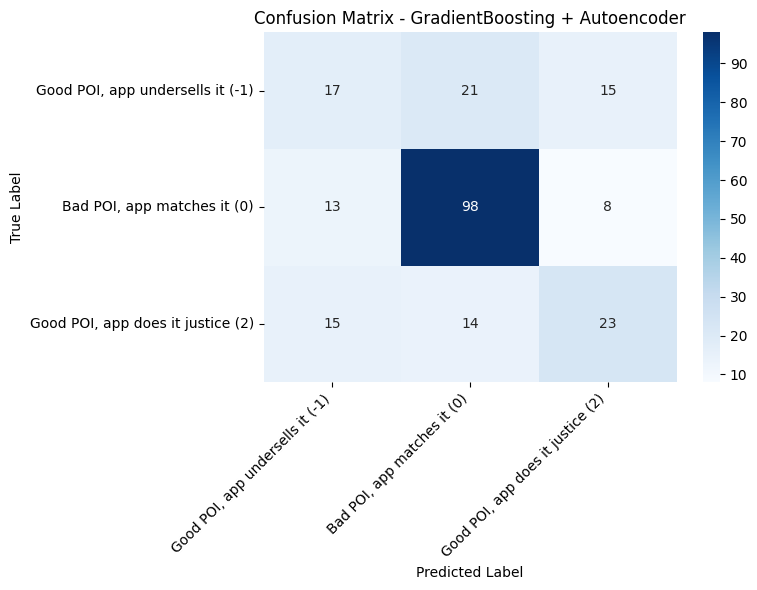


=== GradientBoosting Regressor (metadata + autoencoder) ===
Test MSE: 0.0289
Test MAE: 0.1307
Test R²:  0.4747


In [ ]:
## GradientBoosting with Autoencoder Features

##################################
# Combine metadata + latent vectors
##################################
X_train_ae = np.concatenate([X_train, train_latents], axis=1)
X_val_ae   = np.concatenate([X_val,   val_latents],   axis=1)
X_test_ae  = np.concatenate([X_test,  test_latents],  axis=1)

print(f"Combined feature shape: {X_train_ae.shape}")
# Expected: (1077, 92) = 28 metadata + 64 latent

##################################
# Classification
##################################
print("\n=== GradientBoosting Classifier (metadata + autoencoder) ===")
gb_clf_ae = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf_ae.fit(X_train_ae, y_train_clf)

y_pred_clf_ae = gb_clf_ae.predict(X_test_ae)
accuracy      = 100.0 * (y_pred_clf_ae == y_test_clf).sum() / len(y_test_clf)
print(f"Test Accuracy: {accuracy:.1f}%\n")

present_labels = sorted(list(set(y_test_clf)))
present_names  = [label_names[l] for l in present_labels]

print(classification_report(y_test_clf, y_pred_clf_ae,
                             labels=present_labels,
                             target_names=present_names))

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf_ae, labels=present_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.title('Confusion Matrix - GradientBoosting + Autoencoder')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##################################
# Regression
##################################
print("\n=== GradientBoosting Regressor (metadata + autoencoder) ===")
gb_reg_ae = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg_ae.fit(X_train_ae, y_train_reg)

y_pred_reg_ae = gb_reg_ae.predict(X_test_ae)
mse = np.mean((y_pred_reg_ae - y_test_reg) ** 2)
mae = np.mean(np.abs(y_pred_reg_ae - y_test_reg))
r2  = r2_score(y_test_reg, y_pred_reg_ae)

print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R²:  {r2:.4f}")

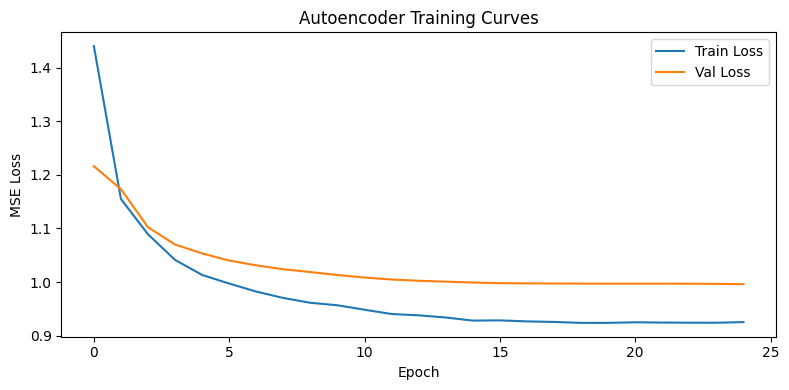

In [ ]:
# Plot results

plt.figure(figsize=(8, 4))
plt.plot(ae_history['train_loss'], label='Train Loss')
plt.plot(ae_history['val_loss'],   label='Val Loss')
plt.title('Autoencoder Training Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Observations about GradientBoosting with Autoencoder

Comparing with GradientBoosting without the image autoencoder, adding the autoencoder features improved the results significantly:

* Regression:

    Metadata only: R² = 0.33, MAE = 0.146
    Metadata + autoencoder: R² = 0.47, MAE = 0.131
    Improvement: +0.14 R² ✓

* Classification

    Metadata only: 52.7% accuracy, macro F1 0.44
    Metadata + autoencoder: 61.6% accuracy, macro F1 0.53
    Improvement: +8.9% accuracy

So the autoencoder is adding useful visual information. But it is far from performing as well as the full deep learning model.